In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
# 1.Import database / data

In [3]:
# Connect to the database
conn = sqlite3.connect("customer_churn.db")

# Get all table names
sql_query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(sql_query, conn)

# Create a DataFrame for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

# Close the connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
# Print table name and column name
conn = sqlite3.connect("customer_churn.db")

for table_name in tables['name']:
    print(f"\nTable Name :")
    # GET COLUMN INFO
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name :
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name :
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name :
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [6]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [7]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [8]:
# 2.Data cleaning

In [9]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [10]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [11]:
# a.remane column - name 
# b.drop columns - interest and pin code
# c.chnge datatype - bod
# d.change datatype of - women ,Men
# e.fix missing values - country

In [12]:
# a.remane column - name 

df_db_customer.rename(columns = {'name': 'customer_name'},inplace = True)

In [13]:
# b.drop columns - interest and pin code

df_db_customer.drop(df_db_customer.columns[-2:],axis=1)

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [14]:
# c.chnge datatype - bod

df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [15]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
 6   interests      4 non-null      str           
 7   pincode        0 non-null      object        
dtypes: datetime64[us](1), object(1), str(6)
memory usage: 1.4+ KB


In [16]:
# d.change datatype of - women ,Men(standardization)

# df_db_customer['gender'].unique()

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male' , 'Women':'Female'})

In [17]:
# Create state -> country mapping
state_country_mapping = (
    df_db_customer
    .dropna(subset=['country'])
    .set_index('state')['country']
    .to_dict()
)

# Fill missing country values based on state
df_db_customer['country'] = df_db_customer['country'].fillna(
    df_db_customer['state'].map(state_country_mapping)
)

df_db_customer['country']

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: str

In [18]:
# Subscription Table

In [19]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [20]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [21]:
date_col = [
    'subscription_start_date',
    'renewal_date',
    'cancellation_date'
]

df_db_subscription[date_col] = df_db_subscription[date_col].apply(
    pd.to_datetime, errors='coerce'
)

df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [22]:
# Support data cleaning

In [23]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [24]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [25]:
# Last 2 column delete karna hai

df_db_support.drop(df_db_support.columns[-2:],axis=1)

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [26]:

df_db_support['complaint_date'] = df_db_support['complaint_date'].apply(
    pd.to_datetime, errors='coerce'
)

df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
 4   col_1           0 non-null      object        
 5   comment         4 non-null      str           
dtypes: datetime64[us](1), int64(1), object(1), str(3)
memory usage: 564.0+ bytes


In [27]:
# Feature Engineering and Data Analysis

In [28]:
# Create a new column using existing column - churn flag

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [29]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [30]:
df = (df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))

df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score,col_1,comment
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,travel,None,NaT,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,NaN,None,2024-08-28,N,60.0,None,service issue
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,NaN,None,2024-08-28,Y,10.0,None,demaned refund
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Delhi,Female,1978-02-15,movie,None,NaT,NaN,NaN,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Nagaland,Male,2001-08-30,NaN,None,NaT,NaN,NaN,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,drama,None,2024-01-20,Y,20.0,None,NaN
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,Delhi,Female,1988-12-10,NaN,None,2025-03-18,N,90.0,None,guidance to renew
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Meghalaya,Female,1976-09-21,NaN,None,2024-11-01,N,30.0,None,NaN
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,Rajasthan,Male,1999-03-14,NaN,None,NaT,NaN,NaN,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,Kathmandu,Female,1985-07-07,NaN,None,NaT,NaN,NaN,NaN,NaN


In [31]:
df.shape

(23, 24)

In [32]:
df_db_subscription['customerid'].nunique()

21

In [33]:
df_db_customer['customerid'].nunique()

21

In [34]:
df_db_support['customerid'].nunique()

7

In [35]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,None,service issue
1,0003-MKNFE,2024-08-28,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None,NaN
3,0013-MHZWF,2025-03-18,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None,NaN
5,0017-IUDMW,2024-04-10,Y,25,None,NaN
6,0019-EFAEP,2024-09-27,Y,30,None,NaN
7,0022-TCJCI,2024-09-13,Y,10,None,NaN
8,0022-TCJCI,2024-09-14,N,90,None,received refund


In [36]:
df_db_support['customer_count'] = (
    df_db_support.groupby('customerid')['customerid']
    .transform('size')
)

In [37]:
df_db_support = (
    df_db_support
    .sort_values(by='customerid')
    .drop_duplicates(subset='customerid', keep='last')
)

In [38]:
df_db_support 

,customerid,complaint_date,escalations,csat_score,col_1,comment,customer_count
1,0003-MKNFE,2024-08-28,Y,10,None,demaned refund,2
2,0013-EXCHZ,2024-01-20,Y,20,None,NaN,1
3,0013-MHZWF,2025-03-18,N,90,None,guidance to renew,1
4,0013-SMEOE,2024-11-01,N,30,None,NaN,1
5,0017-IUDMW,2024-04-10,Y,25,None,NaN,1
6,0019-EFAEP,2024-09-27,Y,30,None,NaN,1
8,0022-TCJCI,2024-09-14,N,90,None,received refund,2


In [39]:
# First fix support table then merge

df = (df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))

df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,interests,pincode,complaint_date,escalations,csat_score,col_1,comment,customer_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Male,1982-04-12,travel,None,NaT,NaN,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23,NaN,None,2024-08-28,Y,10.0,None,demaned refund,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Female,1978-02-15,movie,None,NaT,NaN,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Male,2001-08-30,NaN,None,NaT,NaN,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Female,1990-05-05,drama,None,2024-01-20,Y,20.0,None,NaN,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,Female,1988-12-10,NaN,None,2025-03-18,N,90.0,None,guidance to renew,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Female,1976-09-21,NaN,None,2024-11-01,N,30.0,None,NaN,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,Male,1999-03-14,NaN,None,NaT,NaN,NaN,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,Female,1985-07-07,NaN,None,NaT,NaN,NaN,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,Male,1993-10-29,NaN,None,NaT,NaN,NaN,NaN,NaN,NaN


In [40]:
df.shape

(21, 25)

In [41]:
df.to_csv('exported_churu_data.csv',index=False)

In [42]:
# Data Analysis

In [43]:
# churn Rate

In [44]:
churn_rate = df['churn_flag'].mean()*100
print("Churn rating :", round(churn_rate,2),"%")

Churn rating : 28.57 %


In [45]:
# 2.Retension Rate

retension_rate = 100 - churn_rate
print("Retension rating :", round(retension_rate,2),"%")

Retension rating : 71.43 %


In [46]:
# 3.Churn by plane type

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [47]:
# ARPU - Average revenue per user

In [48]:
arpu = df['monthly_charges'].mean()

print('ARPU =',round(arpu,2))

ARPU = 18.85


In [49]:
# 6. Average Customer Tenure
# Count the number of days a customer has used the service

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tensure = df['tenure_days'].mean()
print("Average tensure(DAYS) = ",round(avg_tensure))

Average tensure(DAYS) =  1494


In [50]:
# Revenue at risk

revenue_at_risk = df.loc[df['churn_flag'] == 1,'monthly_charges'].sum()
print("Revenue at risk (Rs 'K') :",revenue_at_risk)


Revenue at risk (Rs 'K') : 73.94


In [51]:
# 8.Esclation Rate

esclation_rate = (df['escalations'] == 'Y').mean()*100
print("Esclation Rate = ",round(esclation_rate,2),"%")

Esclation Rate =  19.05 %


In [52]:
# 9.Average complain rate per user

avg_customer_count = df['customer_count'].sum() / df['customerid'].nunique()
print(avg_customer_count)

0.42857142857142855


In [53]:
# Correlation Esclation Rate vs churn

df['escalations'] = np.where(df['escalations'] == 'Y' , 1 ,0) # Encoding string to int type

corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

print("Correlation:", correlation)

Correlation: 0.7669649888473702


In [54]:
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [55]:
# Churn risk - create a column using existing col

conditions = [
   (df['churn_score'] < 50),
   (df['churn_score'] >= 50) & (df['churn_score'] < 70),
   (df['churn_score'] >= 70),
]

choises = ['low','med','high']

df['churn_risk'] = np.select(conditions,choises,default="unkown")

In [56]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'col_1', 'comment', 'customer_count', 'tenure_days', 'churn_risk'],
      dtype='str')

In [57]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [58]:
# Visualization using Matplotlib

In [59]:
df_visual = df.copy()

df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'col_1', 'comment', 'customer_count', 'tenure_days', 'churn_risk'],
      dtype='str')

In [60]:
# 4.1 Monthly churn Trends (Time Series API)

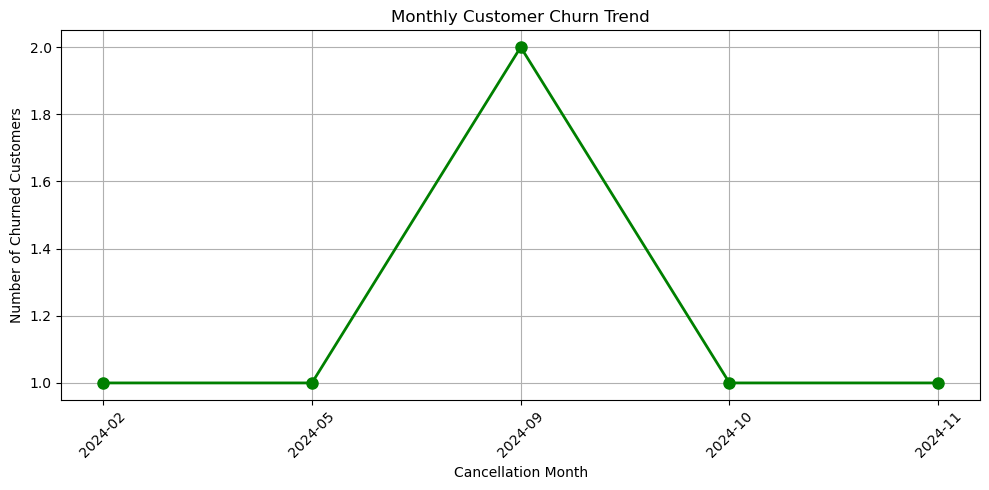

In [61]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = (
    df_visual[df_visual['churn_flag'] == 1]
    .groupby('cancellation_month')
    .size()
)

plt.figure(figsize=(10, 5))

plt.plot(
    churn_trend.index.astype(str),
    churn_trend.values,
    marker='o',
    color='green',
    linewidth=2,
    markersize=8
)

plt.title("Monthly Customer Churn Trend")
plt.xlabel("Cancellation Month")
plt.ylabel("Number of Churned Customers")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig("plots/monthly_customer_churn_trend.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

In [62]:
# 4.2 Churn by plan type

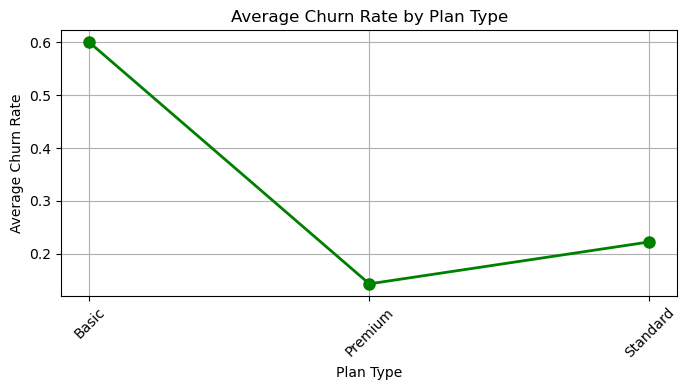

In [63]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(7, 4))

plt.plot(
    churn_plan.index.astype(str),
    churn_plan.values,
    marker='o',
    color='green',
    linewidth=2,
    markersize=8
)

plt.title("Average Churn Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Average Churn Rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig("plots/churn_rate_by_plan_type.png", dpi=300, bbox_inches="tight")

plt.show()

In [64]:
# 4.3 Churn by states

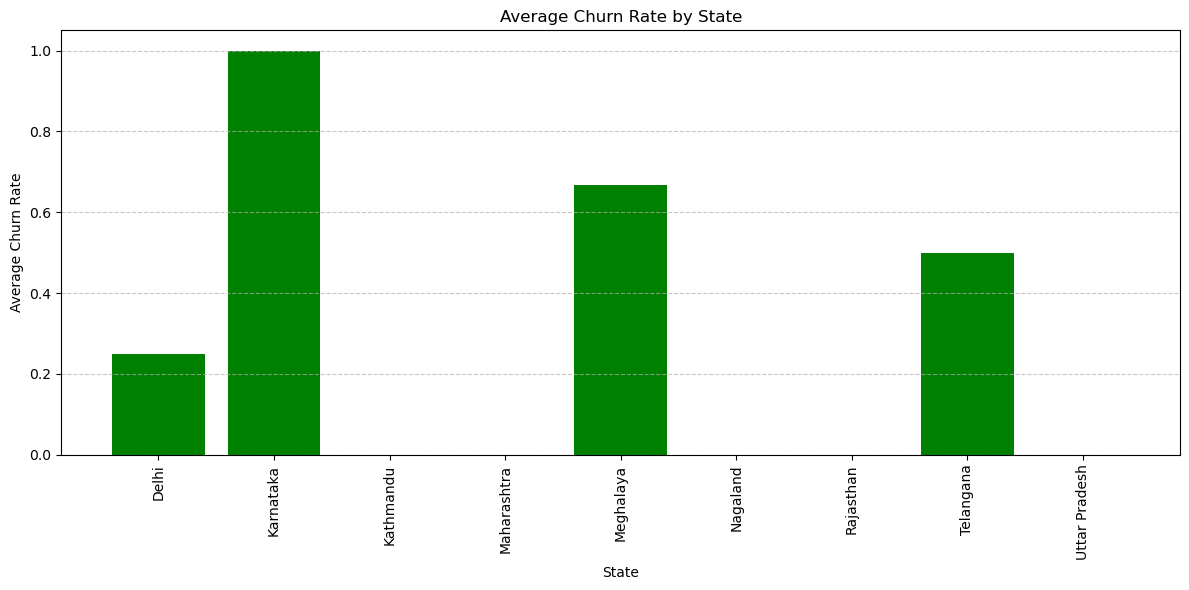

In [65]:
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

plt.figure(figsize=(12, 6))

plt.bar(
    churn_plan.index.astype(str),
    churn_plan.values,
    color='green'
)

plt.title("Average Churn Rate by State")
plt.xlabel("State")
plt.ylabel("Average Churn Rate")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plt.savefig("plots/churn_rate_by_state.png", dpi=300, bbox_inches="tight")

plt.show()

In [66]:
# visualization using seaborn

In [67]:
# Encoding convert str - numeric so that we can find corr between feature

df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'col_1', 'comment', 'customer_count', 'tenure_days', 'churn_risk',
       'cancellation_month'],
      dtype='str')

In [68]:
df_encoded = df_visual[
    ['plan_type', 'contract_type', 'churn_score',
     'churn_flag', 'escalations', 'churn_risk']
].head().copy()

order_mapping = {
    'plan_type': ['Basic', 'Premium', 'Standard'],
    'contract_type': ['Annual', 'Monthly'],
    'churn_risk': ['low', 'med', 'high']
}

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

print(df_encoded)

   plan_type  contract_type  churn_score  churn_flag  escalations  churn_risk
0          2              0           12           0            0           0
1          1              0           91           1            1           2
2          0              1           34           0            0           0
3          1              0            8           0            0           0
4          2              1           88           1            1           2


In [69]:
df_visual['churn_risk'].unique()

<StringArray>
['low', 'high', 'med']
Length: 3, dtype: str

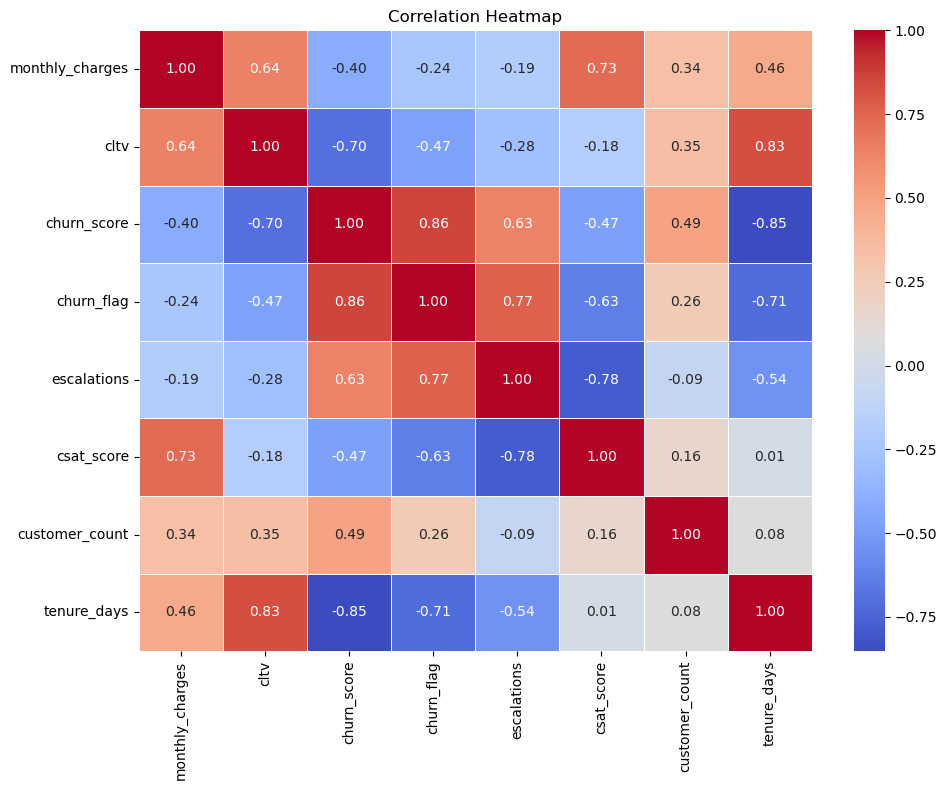

In [70]:

corr_matrix = df_visual.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

# Save the heatmap
plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

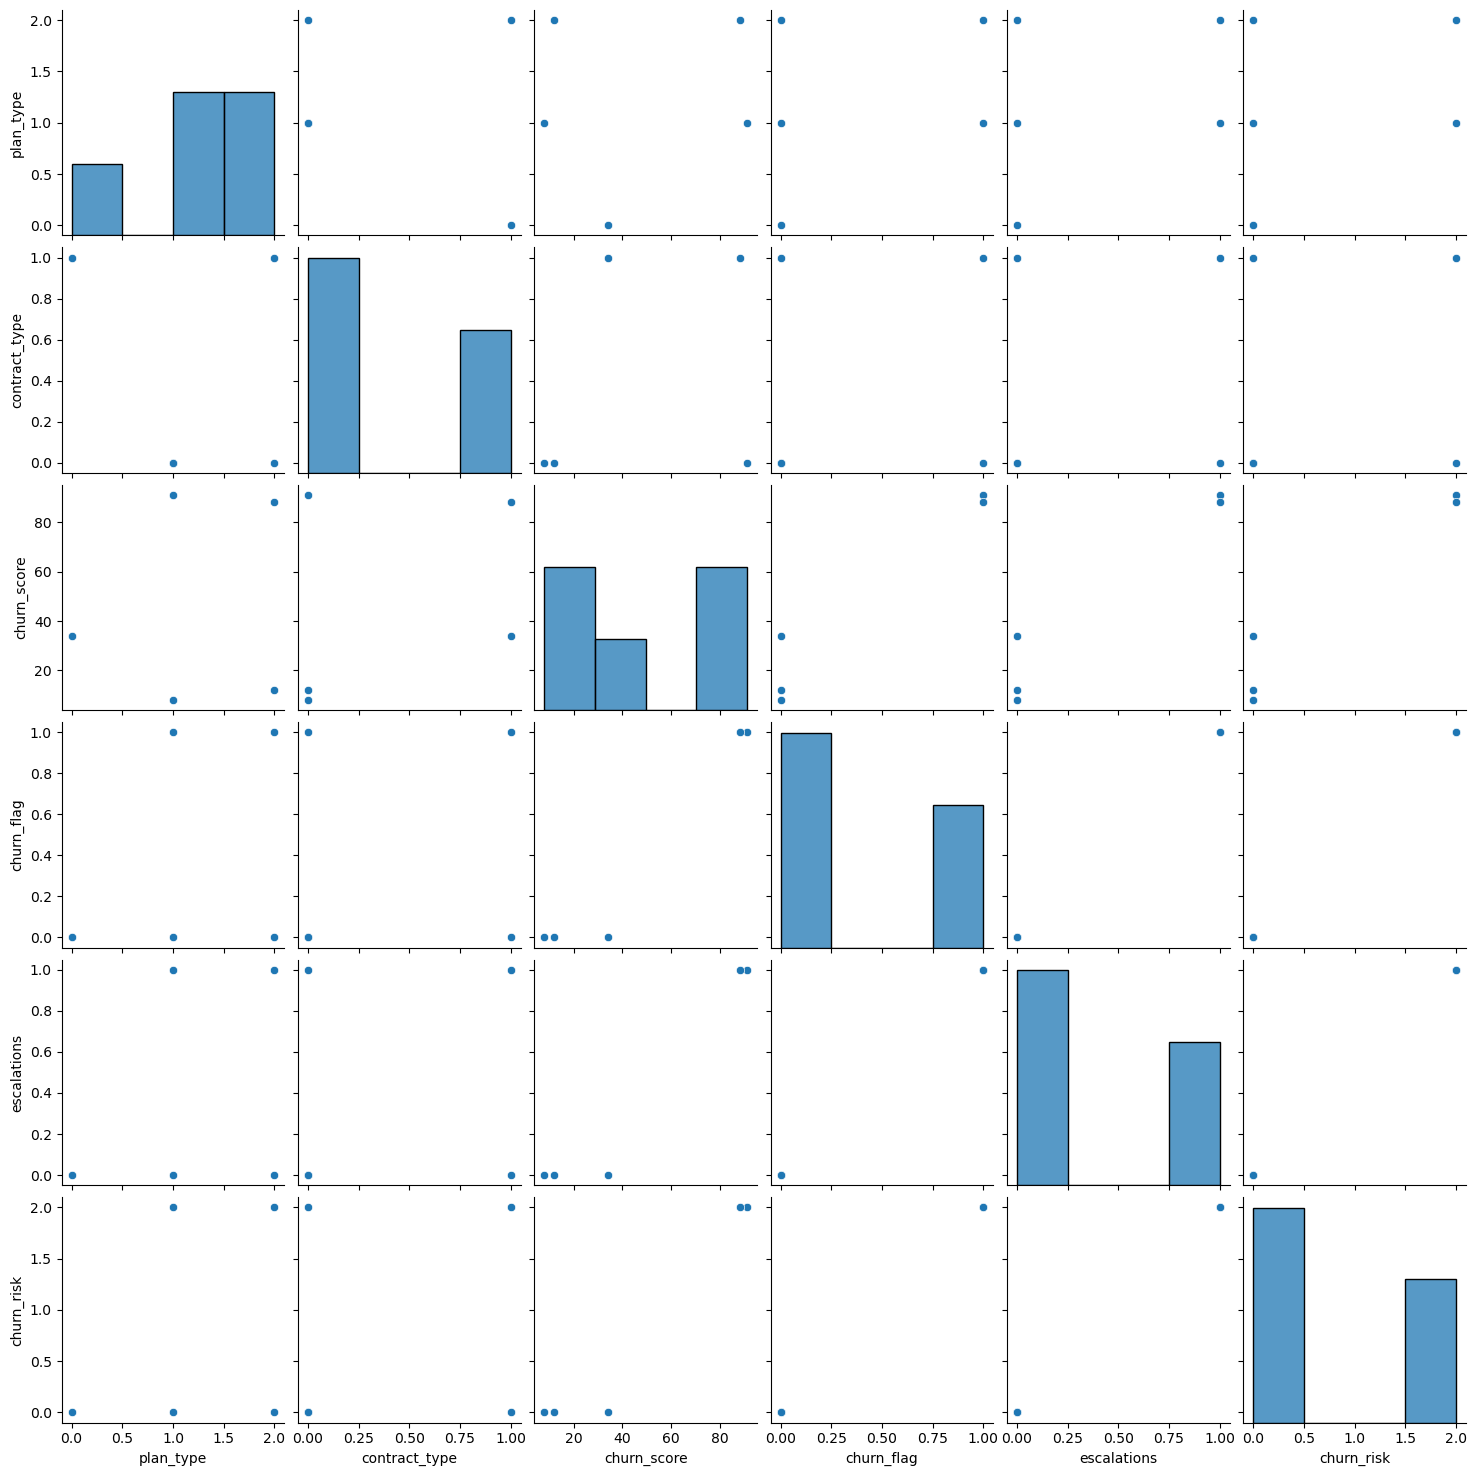

In [71]:
# Pairplot - relationship in a dataset

# Pairplot
pair_plot = sns.pairplot(df_encoded)

# Save the figure
pair_plot.savefig("plots/pairplot_relationship_dataset.png", dpi=300, bbox_inches="tight")

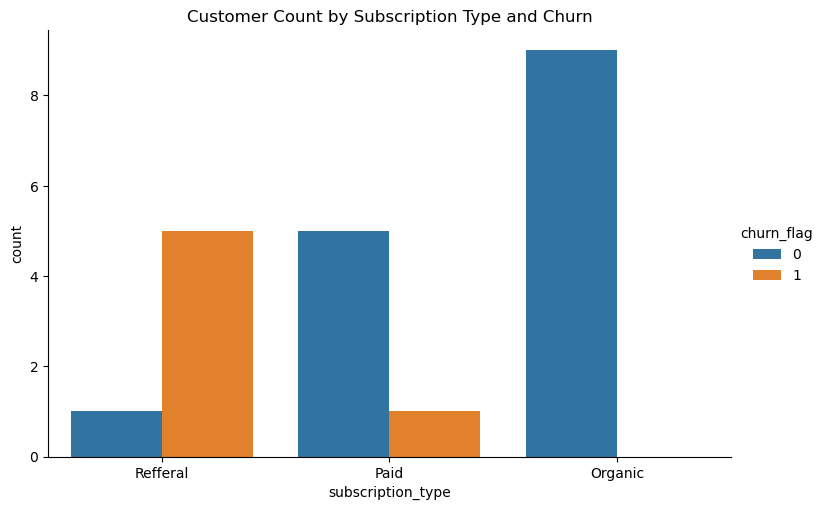

In [72]:
# catplt / Facegrid plot - multi-dimension comparision

sns.catplot(
    data=df_visual,
    x="subscription_type",
    hue="churn_flag",
    kind="count",
    height=5,
    aspect=1.5
)

plt.title("Customer Count by Subscription Type and Churn")
plt.show()

In [73]:
# Pivot Table

In [76]:
pivot_df = (
    pd.pivot_table(
        df_visual,
        values="churn_flag",
        index="plan_type",
        aggfunc="mean"
    )
    .reset_index()
    .rename(columns={"churn_flag": "churn_rate"})
)

print(pivot_df)

  plan_type  churn_rate
0     Basic    0.600000
1   Premium    0.142857
2  Standard    0.222222
